Q:\Program Files (x86)\TEMP\ipykernel_18496\1053326444.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


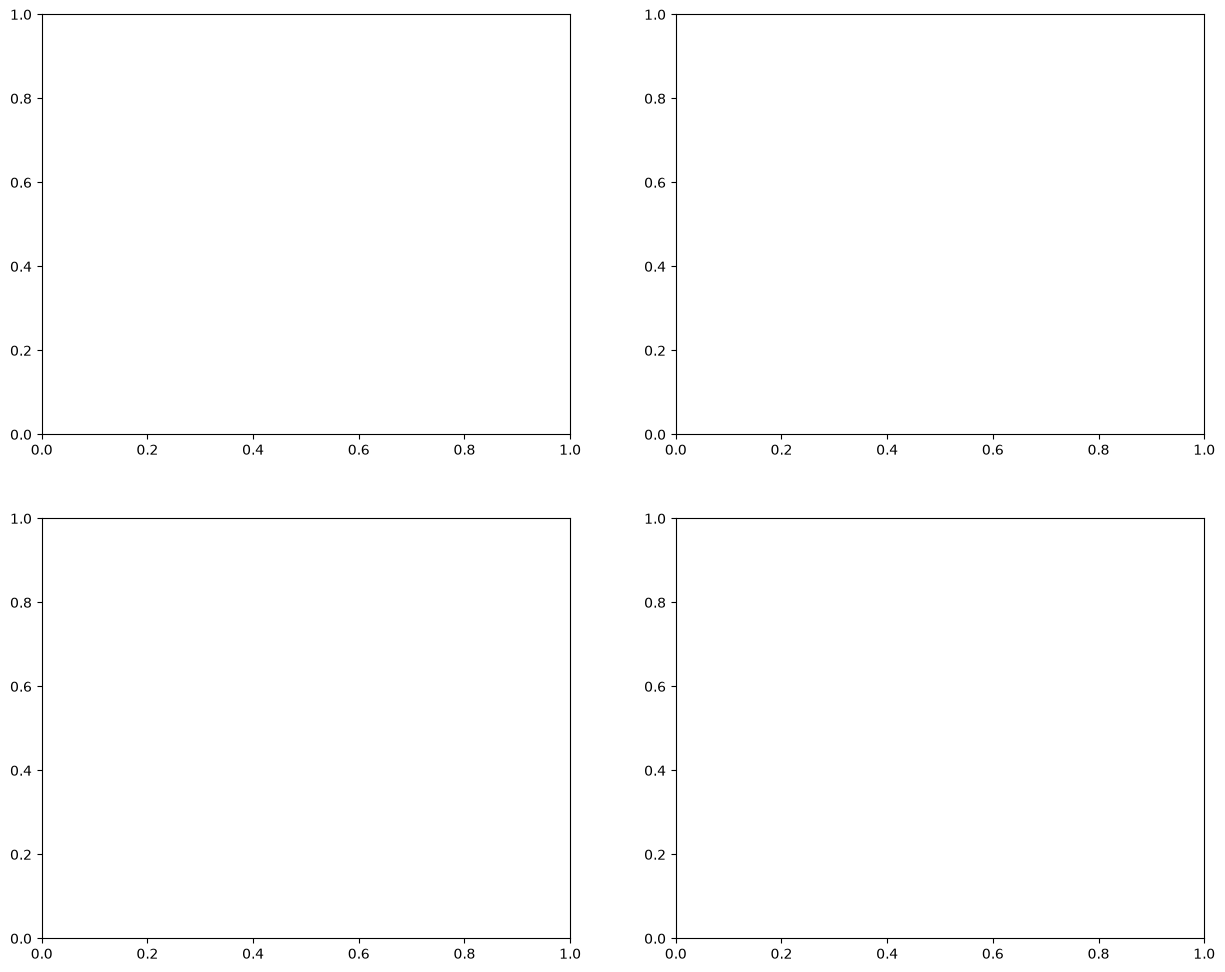

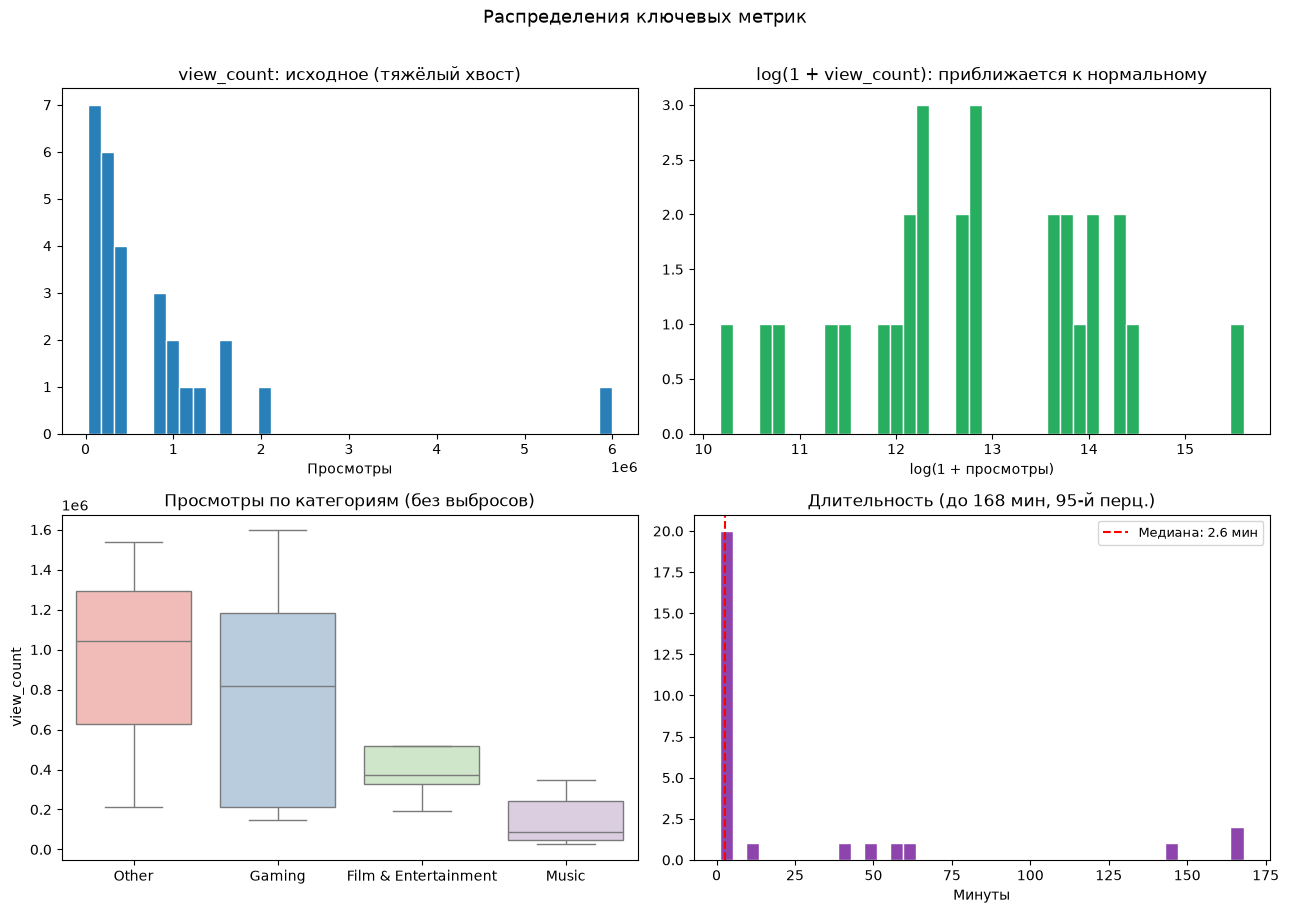

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3  # <- обязательно добавляем этот импорт!

# СЮДА ДОБАВЛЯЕМ ЗАГРУЗКУ ДАННЫХ:
conn = sqlite3.connect('../data/youtube.db')
df = pd.read_sql_query("SELECT * FROM ml_features", conn)
conn.close()

# Инициализируем сетку графиков 2х2
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

df = pd.read_parquet('../data/features.parquet') 
 
fig, axes = plt.subplots(2, 2, figsize=(13, 9)) 
 
# 1) view_count: исходное vs логарифмическое распределение 
axes[0,0].hist(df['view_count'], bins=40, color='#2980B9', edgecolor='white') 
axes[0,0].set_title('view_count: исходное (тяжёлый хвост)') 
axes[0,0].set_xlabel('Просмотры') 
axes[0,0].ticklabel_format(axis='x', style='sci', scilimits=(6,6)) 
 
axes[0,1].hist(np.log1p(df['view_count']), bins=40, color='#27AE60', edgecolor='white') 
axes[0,1].set_title('log(1 + view_count): приближается к нормальному') 
axes[0,1].set_xlabel('log(1 + просмотры)') 
 
# 2) Boxplot view_count по категориям
cat_order = df.groupby('category')['view_count'].median().sort_values(ascending=False).index

# ИСПОЛЬЗУЕМ SEABORN: обратите внимание на ax=axes[1,0]
sns.boxplot(
    data=df,
    x='category',
    y='view_count',
    ax=axes[1,0],
    order=cat_order,
    showfliers=False,
    palette='Pastel1'
)

axes[1,0].set_title('Просмотры по категориям (без выбросов)')
axes[1,0].set_xlabel('')
axes[1,0].set_ylabel('view_count')

# 3) duration_sec: выброс (12 ч) делает гистограмму нечитаемой без ограничения 
clip_sec = df['duration_sec'].quantile(0.95)  # 95-й перцентиль ~ 43 000 сек 
axes[1,1].hist(df['duration_sec'].clip(upper=clip_sec) / 60, 
               bins=40, color='#8E44AD', edgecolor='white') 
axes[1,1].axvline(df['duration_sec'].median()/60, color='red', ls='--', 
                   label=f'Медиана: {df["duration_sec"].median()/60:.1f} мин') 
axes[1,1].set_title(f'Длительность (до {clip_sec/60:.0f} мин, 95-й перц.)') 
axes[1,1].set_xlabel('Минуты'); axes[1,1].legend(fontsize=9) 
 
fig.suptitle('Распределения ключевых метрик', y=1.01, fontsize=13) 
plt.tight_layout() 
plt.savefig('distributions.png', dpi=150, bbox_inches='tight') 
plt.show() 

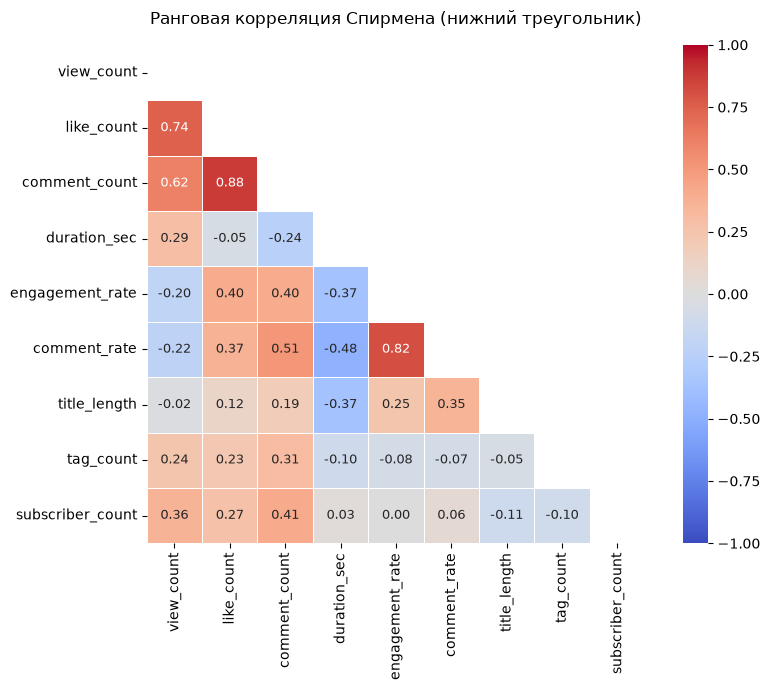

In [8]:
# Метод Спирмена — для непараметрических (ненормальных) распределений 
num_cols = ['view_count', 'like_count', 'comment_count', 
            'duration_sec', 'engagement_rate', 'comment_rate', 
            'title_length', 'tag_count', 'subscriber_count'] 
 
# Убираем признаки, которых может не быть при mock-данных 
num_cols = [c for c in num_cols if c in df.columns] 
 
corr = df[num_cols].corr(method='spearman') 
 
fig, ax = plt.subplots(figsize=(9, 7)) 
mask = np.triu(np.ones_like(corr, dtype=bool))  # показываем только нижний треугольник 
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, ax=ax, 
            linewidths=0.5, square=True, annot_kws={'size':9}) 
ax.set_title('Ранговая корреляция Спирмена (нижний треугольник)', pad=15) 
plt.tight_layout() 
plt.savefig('correlation.png', dpi=150) 
plt.show() 
 
# Вывод студента (обязателен):  
# 'Наибольшая корреляция с view_count — у like_count (0.46). 
# Это ожидаемо: популярные видео набирают всё сразу. 
# Включать like_count в предиктивную модель нельзя, если задача — 
# спрогнозировать популярность ДО публикации...' 

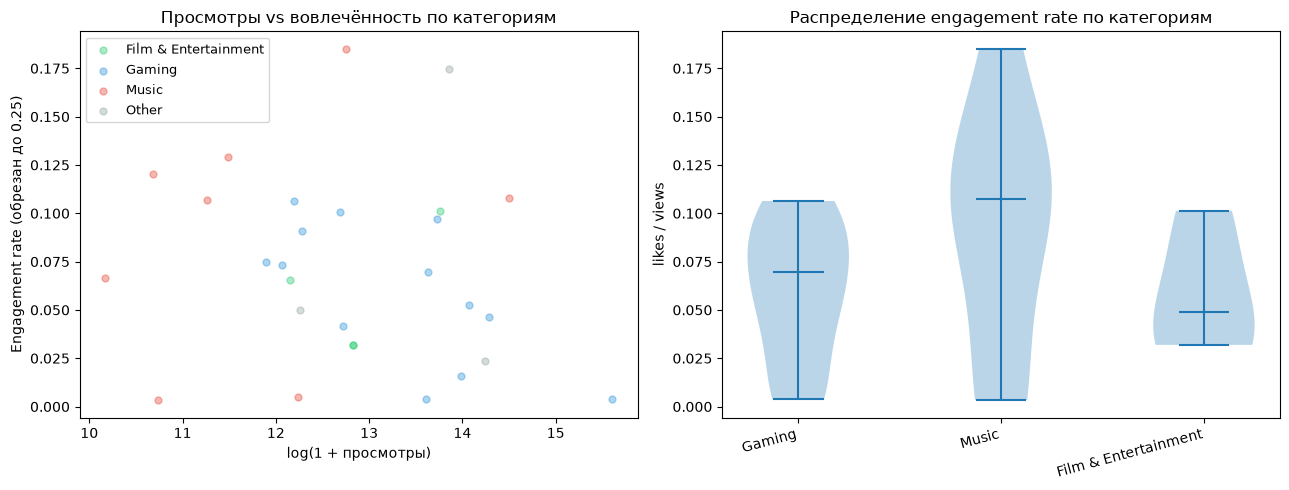

In [9]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5)) 
 
# Scatter: view_count vs engagement_rate с раскраской по категории 
palette = {'Gaming':'#3498DB', 'Music':'#E74C3C', 
           'Film & Entertainment':'#2ECC71', 'Other':'#95A5A6'} 
 
for cat, group in df.groupby('category'): 
    axes[0].scatter(np.log1p(group['view_count']), 
                   group['engagement_rate'].clip(upper=0.25), 
                   alpha=0.4, s=25, label=cat, 
                   color=palette.get(cat, '#95A5A6')) 
axes[0].set_xlabel('log(1 + просмотры)') 
axes[0].set_ylabel('Engagement rate (обрезан до 0.25)') 
axes[0].set_title('Просмотры vs вовлечённость по категориям') 
axes[0].legend(fontsize=9) 
 
# Violin plot engagement_rate по категориям 
cats = ['Gaming', 'Music', 'Film & Entertainment'] 
data = [df.loc[df['category']==c, 'engagement_rate'].dropna().clip(upper=0.25) 
        for c in cats] 
vp = axes[1].violinplot(data, showmedians=True, showextrema=True) 
axes[1].set_xticks(range(1, len(cats)+1)) 
axes[1].set_xticklabels(cats, rotation=15, ha='right') 
axes[1].set_title('Распределение engagement rate по категориям') 
axes[1].set_ylabel('likes / views') 
 
plt.tight_layout() 
plt.savefig('engagement.png', dpi=150) 
plt.show() 

Q:\Program Files (x86)\TEMP\ipykernel_18496\151534743.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
Q:\Program Files (x86)\TEMP\ipykernel_18496\151534743.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['Без тегов', 'С тегами'])


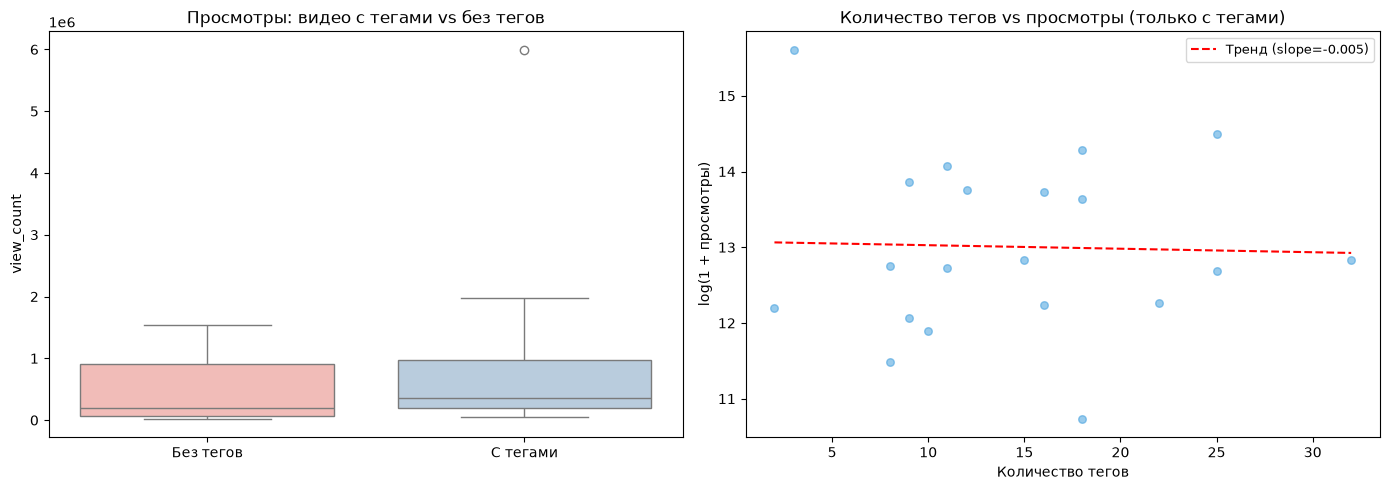

In [10]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Гарантированно загружаем данные из базы данных
conn = sqlite3.connect('../data/youtube.db')
df = pd.read_sql_query("SELECT * FROM ml_features", conn)
conn.close()

# 2. Создаем сетку из двух графиков
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Левый график: Сравнение просмотров с тегами и без через Seaborn ---
sns.boxplot(
    data=df,
    x='has_tags',
    y='view_count',
    ax=axes[0],
    showfliers=True,
    palette='Pastel1'
)
axes[0].set_title('Просмотры: видео с тегами vs без тегов')
axes[0].set_xlabel('')
axes[0].set_ylabel('view_count')
axes[0].set_xticklabels(['Без тегов', 'С тегами'])
axes[0].ticklabel_format(axis='y', style='sci', scilimits=(6,6))

# --- Правый график: Количество тегов vs просмотры ---
tagged = df[df['has_tags'] == 1]
axes[1].scatter(
    tagged['tag_count'], 
    np.log1p(tagged['view_count']),
    alpha=0.5, 
    s=30, 
    color='#3498DB'
)
axes[1].set_xlabel('Количество тегов')
axes[1].set_ylabel('log(1 + просмотры)')
axes[1].set_title('Количество тегов vs просмотры (только с тегами)')

# Линия тренда
m, b = np.polyfit(tagged['tag_count'], np.log1p(tagged['view_count']), 1)
x_line = np.linspace(tagged['tag_count'].min(), tagged['tag_count'].max(), 50)
axes[1].plot(x_line, m * x_line + b, 'r--', linewidth=1.5, label=f'Тренд (slope={m:.3f})')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('tags_analysis.png', dpi=150)
plt.show()
